# Lecture 8 — Solving Ax = b
Instructor: Gilbert Strang

In the previous lecture, we solved:

Ax = 0

and found that all solutions come from the null space of A.

---

Now we move to a new system:

Ax = b

This raises a different question:

Does a solution always exist?

---

If we find one solution xp such that:

A xp = b

and we already know vectors xn such that:

A xn = 0

then combining them gives another solution:

x = xp + xn

---

In this lecture, we will:

- Determine when a solution exists
- Compute a particular solution xp
- Reuse the null space from before
- Build the complete solution step by step

## Section 1 — Revisiting the Matrix A

Before solving Ax = b, we begin by examining the matrix A itself.

The behavior of this system depends entirely on the structure of A.

In particular:

- Which columns are independent?
- Which directions can A produce?

We start by defining the same matrix used previously.

In [1]:
import numpy as np
from sympy import Matrix
from sympy.printing.pretty.pretty_symbology import line_width

A = np.array([
    [1, 2, 2, 2],
    [2, 4, 6, 8],
    [3, 6, 8, 10]
])
print("A: ")
display(Matrix(A))

A: 


Matrix([
[1, 2, 2,  2],
[2, 4, 6,  8],
[3, 6, 8, 10]])

### Inspecting the Structure of A

Before performing elimination, we look for visible patterns in the matrix.

Check if some columns or rows can be written as combinations of others.

This can already indicate whether the matrix has full independence or not.

In [2]:
A_c1 = A[:, 0]
A_c2 = A[:, 1]
A_c3 = A[:, 2]
A_c4 = A[:, 3]

print("Column 1 of A:")
display(Matrix(A_c1))
print("Column 2 of A:")
display(Matrix(A_c2))

A_c2_from_c1 = A_c1 * 2
print("Column 2 of A from Column 1:")
display(Matrix(A_c2_from_c1))

Column 1 of A:


Matrix([
[1],
[2],
[3]])

Column 2 of A:


Matrix([
[2],
[4],
[6]])

Column 2 of A from Column 1:


Matrix([
[2],
[4],
[6]])

In [3]:
A_r1 = A[0, :]
A_r2 = A[1, :]
A_r3 = A[2, :]
print("Row 1 of A:")
display(Matrix(A_r1))
print("Row 2 of A:")
display(Matrix(A_r2))
print("Row 3 of A:")
display(Matrix(A_r3))

A_r3_from_r1_plus_r2 = A_r1 + A_r2
print("Row 3 of A from Row 1 and Row 2:")
display(Matrix(A_r3_from_r1_plus_r2))

Row 1 of A:


Matrix([
[1],
[2],
[2],
[2]])

Row 2 of A:


Matrix([
[2],
[4],
[6],
[8]])

Row 3 of A:


Matrix([
[ 3],
[ 6],
[ 8],
[10]])

Row 3 of A from Row 1 and Row 2:


Matrix([
[ 3],
[ 6],
[ 8],
[10]])

### Observations

We see that:

- Some columns are dependent
- Some rows are combinations of others

This means the matrix does not have full rank.

However, to understand the structure precisely, we perform elimination.

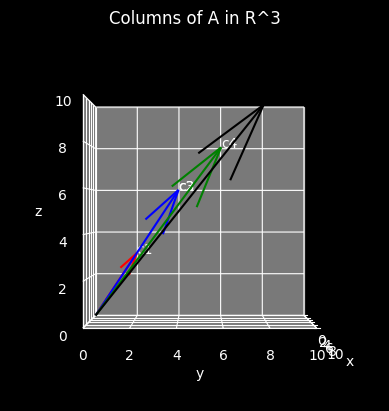

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
origin = np.zeros(3)

ax.quiver(*origin, *A_c1, color='red')
ax.quiver(*origin, *A_c2, color='blue')
ax.quiver(*origin, *A_c3, color='green')
ax.quiver(*origin, *A_c4, color='black')

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_zlim(0, 10)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.set_title('Columns of A in R^3')

ax.text(*A_c1, 'c1')
ax.text(*A_c2, 'c2')
ax.text(*A_c2, 'c3')
ax.text(*A_c3, 'c4')

ax.view_init(elev=0, azim=0)
ax.set_box_aspect([1, 1, 1])
plt.show()

### Why Elimination?

Gaussian elimination reveals:

- Pivot positions
- Independent columns
- The true structure of the matrix

These will determine:

- Which variables are constrained
- Which variables are free

In [10]:
U = A.copy()

U[1, :] = U[1, :] - 2 * U[0, :]
U[2, :] = U[2, :] - 3 * U[0, :]
U[2, :] = U[2, :] - U[1, :]

print("U: ")
display(Matrix(U))

U: 


Matrix([
[1, 2, 2, 2],
[0, 0, 2, 4],
[0, 0, 0, 0]])

### Echelon Form and Pivot Positions

From the elimination, we observe:

- The first pivot appears in column 1
- The second pivot appears in column 3
- The last row becomes zero

This tells us:

- Only two columns are independent
- The rank of A is 2

### Pivot and Free Variables

Since only two columns contain pivots:

- Pivot variables: x1, x3
- Free variables: x2, x4

Free variables appear because some columns are combinations of others.

They represent directions where A does not impose constraints.

### Conclusion of This Section

The matrix A has only two pivot columns.

This means:

- A cannot produce every vector in R^3
- Its outputs are limited to a smaller subspace

In the next section, we will see how this affects solving:

Ax = b

and why not every b leads to a solution.

## Section 2 — Augmented Matrix [A | b]

We now move from:

Ax = 0

to:

Ax = b

---

Instead of solving immediately, we first ask:

Does a solution exist for any vector b?

To answer this, we include b directly into the system and perform elimination.

### Defining the Vector b

We treat b as part of the system:

b = [b1, b2, b3]

At this stage, we do not assume anything about b.

The goal is to see how elimination affects both A and b together.

In [11]:
from sympy import symbols

b1, b2, b3 = symbols('b1, b2, b3')
A_b = Matrix([
    [1, 2, 2, 2, b1],
    [2, 4, 6, 8, b2],
    [3, 6, 8, 10, b3]
])
print("A with b: ")
Matrix(A_b)

A with b: 


Matrix([
[1, 2, 2,  2, b1],
[2, 4, 6,  8, b2],
[3, 6, 8, 10, b3]])

### Why Use the Augmented Matrix?

When we perform row operations on A, we must apply the same operations to b.

This keeps the system Ax = b consistent.

By working with [A | b], we track how the equations transform together.

### Applying Elimination

We now perform the same row operations used earlier on A.

The difference is that b will also change.

This will reveal whether the system remains consistent.

In [12]:
U_A_b = A_b.copy()
U_A_b[1, :] = U_A_b[1, :] - 2 * U_A_b[0, :]
U_A_b[2, :] = U_A_b[2, :] - 3 * U_A_b[0, :]
U_A_b[2, :] = U_A_b[2, :] - U_A_b[1, :]
print("A with b after elimination:")
U_A_b

A with b after elimination:


Matrix([
[1, 2, 2, 2,            b1],
[0, 0, 2, 4,    -2*b1 + b2],
[0, 0, 0, 0, -b1 - b2 + b3]])

### Observing the Result

After elimination, the last row becomes:

[0  0  0  0  |  ? ]

The left side is zero, which means:

0 = something

This creates a condition on b.

### Condition for Consistency

From the final row, we obtain:

b3 - b2 - b1 = 0

This must be satisfied for the system to have a solution.

If this condition fails, the system becomes inconsistent.

### Interpretation

The matrix A produces outputs by combining its columns.

This condition means:

Not every vector b can be created from these columns.

Only those that satisfy the relationship from elimination are valid.

In the next section, we will connect this condition to the concept of column space.

## Section 3 — Column Space and Solvability

From elimination, we obtained a condition on b:

not every vector b leads to a solution.

This means that the matrix A cannot produce all possible vectors in R^3.

So the question becomes:

Which vectors b can be written as Ax?

### The Column Space of A

Each column of A is a vector in R^3.

When we compute Ax, we are forming a linear combination of these columns:

Ax = x1*c1 + x2*c2 + x3*c3 + x4*c4

So the result Ax must lie in the space spanned by the columns of A.

This space is called the **column space of A**.

### Connection to the Visualization

In Section 1, we plotted the columns of A in 3D.

We observed:

- Some columns are dependent
- All columns lie in a plane

This means:

The column space of A is not all of R^3, but a plane inside it.

### When Does Ax = b Have a Solution?

The system Ax = b has a solution if and only if:

b lies in the column space of A

In other words:

b must be a combination of the columns of A

---

The condition we found earlier:

b3 - b2 - b1 = 0

is exactly the requirement that b lies in that plane.

### Testing the Condition

We now test two cases:

1. A vector b that satisfies the condition
2. A vector b that does not

This will show how the system behaves in each case.

In [21]:
b_valid = np.array([
    [1],
    [5],
    [6]
])
print("b_valid: ")
display(Matrix(b_valid))
A_b_valid = np.column_stack((A.copy(), b_valid))
print("A with b_valid (Augmented Matrix):")
display(Matrix(A_b_valid))

b_valid: 


Matrix([
[1],
[5],
[6]])

A with b_valid (Augmented Matrix):


Matrix([
[1, 2, 2,  2, 1],
[2, 4, 6,  8, 5],
[3, 6, 8, 10, 6]])

In [22]:
U_A_b_valid = A_b_valid.copy()
U_A_b_valid[1, :] = U_A_b_valid[1, :] - 2 * U_A_b_valid[0, :]
U_A_b_valid[2, :] = U_A_b_valid[2, :] - 3 * U_A_b_valid[0, :]
U_A_b_valid[2, :] = U_A_b_valid[2, :] - U_A_b_valid[1, :]
print("A with b after elimination:")
Matrix(U_A_b_valid)

A with b after elimination:


Matrix([
[1, 2, 2, 2, 1],
[0, 0, 2, 4, 3],
[0, 0, 0, 0, 0]])

In [23]:
b_invalid = np.array([
    [1],
    [5],
    [7]
])
print("b invlaid:")
display(Matrix(b_invalid))
A_b_invalid = np.column_stack((A.copy(), b_invalid))
print("A with b_invalid (Augmented Matrix):")
display(Matrix(A_b_invalid))

b invlaid:


Matrix([
[1],
[5],
[7]])

A with b_invalid (Augmented Matrix):


Matrix([
[1, 2, 2,  2, 1],
[2, 4, 6,  8, 5],
[3, 6, 8, 10, 7]])

In [24]:
U_A_b_invalid = A_b_invalid.copy()
U_A_b_invalid[1, :] = U_A_b_invalid[1, :] - 2 * U_A_b_invalid[0, :]
U_A_b_invalid[2, :] = U_A_b_invalid[2, :] - 3 * U_A_b_invalid[0, :]
U_A_b_invalid[2, :] = U_A_b_invalid[2, :] - U_A_b_invalid[1, :]
print("A with b_invalid after elimination:")
Matrix(U_A_b_invalid)

A with b_invalid after elimination:


Matrix([
[1, 2, 2, 2, 1],
[0, 0, 2, 4, 3],
[0, 0, 0, 0, 1]])

### Visualizing the Column Space

The columns of A span a plane in R^3.

If b lies on this plane, then b can be written as a combination of the columns of A, so Ax = b has a solution.

If b lies outside this plane, then no exact solution exists.

In [28]:
s_value = np.linspace(-1.5, 1.5, 20)
t_value = np.linspace(-1.5, 1.5, 20)

S, T = np.meshgrid(s_value, t_value)

X = S * A_c1[0] + T * A_c3[0]
Y = S * A_c1[1] + T * A_c3[1]
Z = S * A_c1[2] + T * A_c3[2]

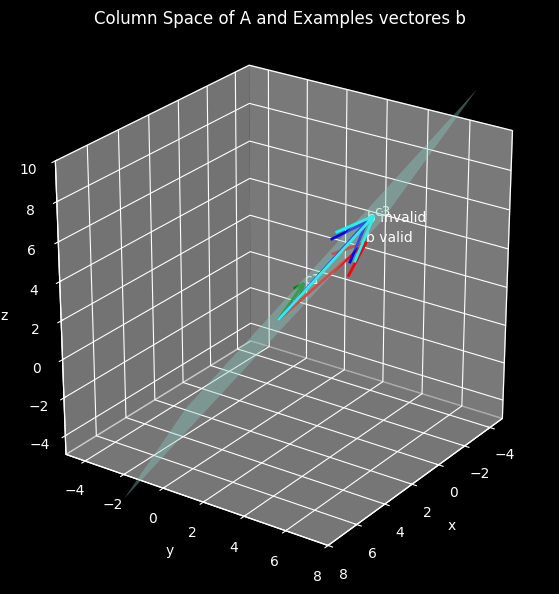

In [69]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y, Z, alpha=0.4, edgecolor='none')

origin = np.zeros(3)

ax.quiver(*origin, *b_valid.ravel(), color='red', linewidth=2)
ax.quiver(*origin, *b_invalid.ravel(), color='blue', linewidth=2)
ax.text(*b_valid.ravel(), "b valid")
ax.text(*b_invalid.ravel(), "b invalid")

ax.quiver(*origin, *A_c1, color='green', linewidth=2)
ax.quiver(*origin, *A_c3, color='cyan', linewidth=2)
ax.text(*A_c1, "c1")
ax.text(*A_c3, "c3")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Column Space of A and Examples vectores b")

ax.set_xlim(-5, 8)
ax.set_ylim(-5, 8)
ax.set_zlim(-5, 10)

ax.view_init(elev=25, azim=35)
ax.set_box_aspect([1, 1, 1])

plt.show()

### Observations

- When b satisfies the condition, elimination produces no contradiction
- The system remains consistent

- When b violates the condition, we get:

0 = non-zero

This means no solution exists

---

This confirms that:

Ax = b is solvable only when b lies in the column space of A

## Section 4 — Finding a Particular Solution xp

When the system Ax = b is consistent, we want to construct one solution.

This solution is called a **particular solution** xp.

Once we have one such solution, we can later build all solutions using the null space.

### Strategy

From elimination, we already know:

- Pivot variables: x1, x3
- Free variables: x2, x4

To find a particular solution:

1. Set all free variables to zero
2. Solve for the pivot variables

In [79]:
R_b_valid = np.column_stack((A.copy(), b_valid)).astype(float)

R_b_valid[1, :] = R_b_valid[1, :] - 2 * R_b_valid[0, :]
R_b_valid[2, :] = R_b_valid[2, :] - 3 * R_b_valid[0, :]
R_b_valid[2, :] = R_b_valid[2, :] - R_b_valid[1, :]

print("echelon form  of A Augmented Matrix:")
display(Matrix(R_b_valid))

R_b_valid[0, :] = R_b_valid[0, :] - R_b_valid[1, :]
R_b_valid[1, :] = R_b_valid[1, :] / 2.0

print("Reduced system of echelon of A Augmented Matrix:")
Matrix(R_b_valid)

echelon form  of A Augmented Matrix:


Matrix([
[1.0, 2.0, 2.0, 2.0, 1.0],
[0.0, 0.0, 2.0, 4.0, 3.0],
[0.0, 0.0, 0.0, 0.0, 0.0]])

Reduced system of echelon of A Augmented Matrix:


Matrix([
[1.0, 2.0, 0.0, -2.0, -2.0],
[0.0, 0.0, 1.0,  2.0,  1.5],
[0.0, 0.0, 0.0,  0.0,  0.0]])

### Reduced System

After elimination, the system becomes:

- First row: relation involving x1, x2, x3, x4
- Second row: relation involving x3, x4

Since we set x2 = 0 and x4 = 0, the system simplifies.

In [82]:
x1, x2, x3, x4 = symbols('x1 x2 x3 x4')
s, t = symbols('s t') # free variables

# from row 2: x3 + 2x4 = 1.5
x3_expr = 1.5 - 2*t

# from row 1: x1 + 2x2 - 2x4 = -2
x1_expr = -2 - 2*s + 2*t

print("\nGeneral solution:")
print(f"x1 = {x1_expr}")
print(f"x2 = {s}")
print(f"x3 = {x3_expr}")
print(f"x4 = {t}")

particular = Matrix([-2, 0, 1.5, 0])
v1 = Matrix([-2, 1, 0, 0]) # coefficient of s
v2 = Matrix([2, 0, -2, 1]) # coefficient of t

print("\nVector form:")
print("x =")
display(particular)
print("+ s *")
display(v1)
print("+ t *")
display(v2)


General solution:
x1 = -2*s + 2*t - 2
x2 = s
x3 = 1.5 - 2*t
x4 = t

Vector form:
x =


Matrix([
[ -2],
[  0],
[1.5],
[  0]])

+ s *


Matrix([
[-2],
[ 1],
[ 0],
[ 0]])

+ t *


Matrix([
[ 2],
[ 0],
[-2],
[ 1]])

Simple Solution

In [83]:
x2_val = 0
x4_val = 0

x1_val = -2 - 2*x2_val + 2*x4_val
x3_val = 1.5 - 2*x4_val

x_simple = np.array([x1_val, x2_val, x3_val, x4_val], dtype=float)
print("Simple Solution:")
print(f"x = {x_simple}")

Simple Solution:
x = [-2.   0.   1.5  0. ]


### Particular Solution

By setting the free variables to zero and solving the reduced system, we obtain one solution:

xp = [-2, 0, 1.5, 0]

In [84]:
print("A @ x_simple =")
print(A @ x_simple.reshape(-1, 1))

print("b_valid =")
print(b_valid)

A @ x_simple =
[[1.]
 [5.]
 [6.]]
b_valid =
[[1]
 [5]
 [6]]


Using Numpy built methodsto find one solution

In [87]:
xp_lstsq, *_ = np.linalg.lstsq(A, b_valid, rcond=None)
print("lstsq solution (One Solution by Numpy):")
print(xp_lstsq)

print("A @ lstsq solution =")
print(A @ xp_lstsq)

lstsq solution (One Solution by Numpy):
[[-0.13793103]
 [-0.27586207]
 [ 0.18965517]
 [ 0.65517241]]
A @ lstsq solution =
[[1.]
 [5.]
 [6.]]


### Interpretation

The particular solution xp is one vector that satisfies Ax = b.

It is not the only solution.

It serves as a starting point from which all other solutions can be constructed.

## Section 5 — The Null Space Contribution

In the previous lecture, we solved:

Ax = 0

and found that all solutions form the null space of A.

---

Now we return to that result.

If xn is any vector in the null space, then:

A xn = 0

This means that adding xn to any solution of Ax = b will produce another solution.

### Null Space of A

From the previous lecture, we found two special solutions:

- v1 = [-2, 1, 0, 0]
- v2 = [ 2, 0, -2, 1]

These vectors span the null space of A.

So any vector xn in the null space can be written as:

xn = c1 * v1 + c2 * v2

In [88]:
v1 = np.array([-2, 1, 0, 0], dtype=float)
v2 = np.array([2, 0, -2, 1], dtype=float)

print("v1 from Null Space vectores:")
display(Matrix(v1))

print("v2 from Null Space vectores:")
display(Matrix(v2))

v1 from Null Space vectores:


Matrix([
[-2.0],
[ 1.0],
[ 0.0],
[ 0.0]])

v2 from Null Space vectores:


Matrix([
[ 2.0],
[ 0.0],
[-2.0],
[ 1.0]])

Verification

In [89]:
A @ v1

array([0., 0., 0.])

In [90]:
A @ v2

array([0., 0., 0.])

### Interpretation

The null space contains all vectors that A maps to zero.

These vectors do not affect the result of Ax.

So if we already have one solution xp, adding any xn will still satisfy:

A(xp + xn) = b

### Building More Solutions

We now have:

- xp → one solution such that Ax = b
- xn → vectors such that Axn = 0

Combining them gives:

x = xp + xn

This describes all possible solutions of the system.

## Section 6 — Complete Solution of Ax = b

We now combine the results from the previous sections.

We have:

- xp → a particular solution such that Axp = b
- xn → all vectors such that Axn = 0

Together, they form the complete solution.

### General Form of the Solution

Any solution x can be written as:

x = xp + xn

From earlier results:

xp = [-2, 0, 1.5, 0]

xn = c1 * [-2, 1, 0, 0] + c2 * [2, 0, -2, 1]

---

So the complete solution becomes:

x = [-2, 0, 1.5, 0] + c1 * [-2, 1, 0, 0] + c2 * [2, 0, -2, 1]

In [91]:
xp = np.array([-2, 0, 1.5, 0])
c1 = 1
c2 = 2

x = xp + c1 * v1 + c2 * v2
print("x complete:")
display(Matrix(x))

x complete:


Matrix([
[ 0.0],
[ 1.0],
[-2.5],
[ 2.0]])

Verification

In [92]:
A @ x

array([1., 5., 6.])

In [95]:
cs1 = [3, 6, 10, 55]
cs2 = [1, 2, 3, 4]

for c1, c2 in zip(cs1, cs2):
    x = xp + c1 * v1 + c2 * v2
    print("x complete:")
    display(Matrix(x))
    print("A @ x complete =", A @ x)

x complete:


Matrix([
[-6.0],
[ 3.0],
[-0.5],
[ 1.0]])

A @ x complete = [1. 5. 6.]
x complete:


Matrix([
[-10.0],
[  6.0],
[ -2.5],
[  2.0]])

A @ x complete = [1. 5. 6.]
x complete:


Matrix([
[-16.0],
[ 10.0],
[ -4.5],
[  3.0]])

A @ x complete = [1. 5. 6.]
x complete:


Matrix([
[-104.0],
[  55.0],
[  -6.5],
[   4.0]])

A @ x complete = [1. 5. 6.]


### Interpretation

The solution to Ax = b is not a single vector.

It is a family of vectors formed by adding the null space to a particular solution.

- xp fixes the requirement Ax = b
- xn allows movement without changing Ax

This explains why multiple solutions can exist.

### Dimension of the Solution Space

The number of free variables determines the number of independent directions in the solution.

In this case:

- Number of variables n = 4
- Rank r = 2

So:

dimension of solution space = n - r = 2

This matches the two null space vectors v1 and v2.

## Section 7 — Rank and Number of Solutions

From the previous sections, we observed:

- Sometimes Ax = b has no solution
- Sometimes it has one solution
- Sometimes it has infinitely many solutions

These outcomes are not random.

They are completely determined by the **rank of A**.

### Key Quantities

Let A be an m × n matrix.

- m → number of equations
- n → number of variables
- r → rank of A (number of pivot columns)

The rank tells us:

- how many independent directions A has
- how many variables are constrained

### Case 1 — Full Column Rank (r = n)

All columns are independent.

This means:

- No free variables
- Null space contains only the zero vector

---

For Ax = b:

- If a solution exists → it is unique
- If no solution exists → the system is inconsistent

So the system has:

0 or 1 solution

### Case 2 — Full Row Rank (r = m)

All rows are independent.

This means:

- No zero rows after elimination
- No consistency restrictions

---

For Ax = b:

- A solution exists for every b
- There are free variables if n > m

So the system has:

infinitely many solutions

### Case 3 — r < m and r < n

The matrix has:

- dependent rows → may lead to inconsistency
- dependent columns → free variables

---

For Ax = b:

- If b satisfies the consistency condition → infinitely many solutions
- If not → no solution

So the system has:

0 or infinitely many solutions

### Case 4 — r = m = n (Square and Full Rank)

The matrix is square and all rows and columns are independent.

This means:

- No free variables
- No consistency issues

---

For Ax = b:

- A unique solution exists for every b

The matrix is invertible.

### Summary

The rank determines everything:

- r = n → no free variables → 0 or 1 solution
- r = m → always solvable → infinite solutions (if n > m)
- r < m and r < n → 0 or infinite solutions
- r = m = n → exactly one solution

---

The structure of A controls both:

- existence of solutions
- number of solutions

### Connection to This Lecture

In our example:

- m = 3, n = 4
- rank r = 2

So:

- r < m → not all b are valid
- r < n → free variables exist

This is why:

- some b have no solution
- valid b produce infinitely many solutions

## Conclusion — Structure of Solutions to Ax = b

In this lecture, we extended the problem from:

Ax = 0
to
Ax = b

and uncovered the full structure of solutions.

---

### 1. Existence of Solutions

A solution to Ax = b exists only when:

b lies in the column space of A

This condition emerged directly from elimination, where consistency required:

0 = 0

---

### 2. Structure of All Solutions

When a solution exists, it can always be written as:

x = xp + xn

Where:

- xp → a particular solution satisfying Axp = b
- xn → any vector in the null space satisfying Axn = 0

---

### 3. Role of the Null Space

The null space describes all directions that do not change Ax.

It determines:

- how many solutions exist
- how solutions can vary

Its dimension is:

n - r

---

### 4. Role of the Rank

The rank of A determines both:

- whether solutions exist
- whether solutions are unique or infinite

---

### 5. Geometric Interpretation

- The columns of A span a subspace of R^m
- Only vectors b inside this subspace can be reached
- When solvable, the solution set forms a shifted version of the null space

---

### Final Insight

The matrix A plays two roles at once:

- It restricts which vectors b are possible (through its column space)
- It shapes all solutions (through its null space)

Understanding these two structures fully describes the behavior of Ax = b.